# Tarea 07 
### Nombre: Eduardo Verdezotto

##### 1) Dados los puntos (0,1),(1,5),(2,3), determine el spline cúbico. 

##### Teniendo las siguientes ecuaciones:
 $[1]~ a_0 = 1$ <br> <br>
 $[2] ~a_0 +b_0 +c_0 +d_0 = 5$ <br> <br>
 $[3] ~a_1 = 5$ <br> <br>
 $[4] ~a_1 + b_1 + c_1 +d_1 = 3$ <br> <br>
 $[5] ~b_0 + 2c_0 + 3d_0 = b1$<br> <br>
 $[6]~ c_0 + 3d_0 = c_1$<br> <br>
 $[7] ~c_0 = 0$<br> <br>
 $[8]~ c_1 + 3d_1 = 0$<br> <br>
 Resultando en los siguientes splines cúbicos:
 $$S_0 (x) = 1+5.5x - \frac{6}{4}x^3$$
 $$S_1 (x) = 5 + (x-1) - 4.5(x-1)^2 + \frac{6}{4}(x-1)^3$$

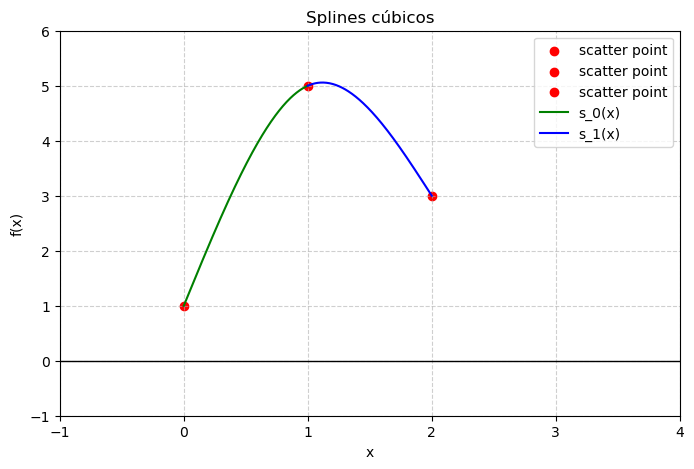

In [3]:
import numpy as np
import matplotlib.pyplot as plt
x0,y0 = 0,1
x1, y1= 1,5
x2, y2= 2,3

xs0 = np.linspace(0, 1, 200)
xs1 = np.linspace(1, 2, 200)
a0= 1
a1= 5
b0= 5.5
b1= 1
c0= 0 
c1= -4.5 
d0= -6/4
d1= 6/4

def s_0(x):
    return a0 + b0 * (x-x0) - c0 * (x - x0) **2 + d0 * (x - x0) **3

def s_1(x):
    return a1 + b1 * (x - x1) + c1 * (x - x1) ** 2 + d1 * (x - x1) ** 3


plt.figure(figsize=(8, 5))
plt.scatter([0.0], [1.0], color='red', label='scatter point')
plt.scatter([1.0], [5.0], color='red', label='scatter point')
plt.scatter([2.0], [3.0], color='red', label='scatter point')
plt.plot(xs0, s_0(xs0), label='s_0(x)', color='green')
plt.plot(xs1, s_1(xs1), label='s_1(x)', color='blue')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Splines cúbicos')
plt.legend()
plt.xlim(-1, 4)
plt.ylim(-1, 6)
plt.show()

##### 2) Dados los puntos (−1,1),(1,3), determine el spline cúbico sabiendo que 𝑓′(𝑥0)=1,𝑓′(𝑥𝑛)=2.

Teniendo las siguientes ecuaciones:

$[1]~ a_0 = 1$ <br> <br>
 $[2] ~a_0 +2b_0 +4c_0 +8d_0 = 3$ <br> <br>
 $[3] ~b_0 = 1$ <br> <br>
 $[4] ~b_0 + 4c_0 +12d_0 = 2$ <br> <br>
 Resultando en los siguientes splines cúbicos:
 $$S_0 (x) = 1+(x+1) - \frac{1}{2}(x+1)^2 - \frac{1}{4}(x+1)^3$$

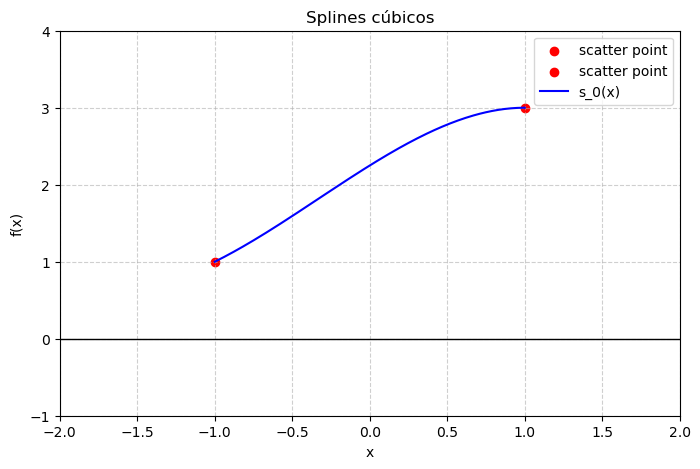

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x0,y0 = -1,1
x1, y1= 1,3

xs0 = np.linspace(-1, 1, 200)
a0= 1
b0= 1
c0= -1/2 
d0= -1/4

def s_0(x):
    return a0 + b0 * (x-x0) - c0 * (x - x0) **2 + d0 * (x - x0) **3

plt.figure(figsize=(8, 5))
plt.scatter([-1.0], [1.0], color='red', label='scatter point')
plt.scatter([1.0], [3.0], color='red', label='scatter point')
plt.plot(xs0, s_0(xs0), label='s_0(x)', color='blue')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Splines cúbicos')
plt.legend()
plt.xlim(-2, 2)
plt.ylim(-1, 4)
plt.show()

##### 3) Diríjase al pseudocódigo del spline cúbico con frontera natural provisto en clase, en base a ese pseudocódigo complete la siguiente función: 
 



In [ ]:
import sympy as sym
from IPython.display import display


# ##################################################################
def cubic_spline(xs: list[float], ys: list[float]) -> list[sym.Symbol]:
    """
    Cubic spline interpolation `S`. Every two points are interpolated by a cubic polynomial
    `S_j` of the form `S_j(x) = a_j + b_j(x - x_j) + c_j(x - x_j)^2 + d_j(x - x_j)^3.`

    xs must be different  but not necessarily ordered nor equally spaced.

    ## Parameters
    - xs, ys: points to be interpolated

    ## Return
    - List of symbolic expressions for the cubic spline interpolation.
    """

    points = sorted(zip(xs, ys), key=lambda x: x[0])  # sort points by x

    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1  

    h = [xs[i + 1] - xs[i] for i in range(n)]  # distances between contiguous xs

    alpha = [0] * n
    for i in range(1, n):
        alpha[i] = 3 / h[i] * (ys[i + 1] - ys[i]) - 3 / h[i - 1] * (ys[i] - ys[i - 1])

    l = [1]
    u = [0]
    z = [0]

    for i in range(1, n):
        l += [2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1]]
        u += [h[i] / l[i]]
        z += [(alpha[i] - h[i - 1] * z[i - 1]) / l[i]]

    l.append(1)
    z.append(0)
    c = [0] * (n + 1)

    x = sym.Symbol("x")
    splines = []
    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b = (ys[j + 1] - ys[j]) / h[j] - h[j] * (c[j + 1] + 2 * c[j]) / 3
        d = (c[j + 1] - c[j]) / (3 * h[j])
        a = ys[j]
        S = a + b*(x - xs[j]) + c[j]*(x - xs[j])**2 + d*(x - xs[j])**3

        print(j, a, b, c[j], d)
        splines.append(S)

    splines.reverse()
    return splines

4) Usando la función anterior, encuentre el spline cúbico para

$$xs = [1,2,3]$$
$$yx = [2,3,5]$$

In [8]:
xs = [1, 2, 3]
ys = [2, 3, 5]

splines = cubic_spline(xs=xs, ys=ys)
_ = [display(s) for s in splines]
print("______")
_ = [display(s.expand()) for s in splines]

1 3 1.5 0.75 -0.25
0 2 0.75 0.0 0.25


0.75*x + 0.25*(x - 1)**3 + 1.25

1.5*x - 0.25*(x - 2)**3 + 0.75*(x - 2)**2

______


0.25*x**3 - 0.75*x**2 + 1.5*x + 1.0

-0.25*x**3 + 2.25*x**2 - 4.5*x + 5.0

5. Usando la función anterior, encuentre el spline cúbico para:


$$xs = [0,1,2,3]$$
$$yx = [-1,1,5,2]$$

In [9]:
xs = [0,1, 2, 3]
ys = [-1,1,5,2]

splines = cubic_spline(xs=xs, ys=ys)
_ = [display(s) for s in splines]
print("______")
_ = [display(s.expand()) for s in splines]

2 5 1.0 -6.0 2.0
1 1 4.0 3.0 -3.0
0 -1 1.0 0.0 1.0


1.0*x**3 + 1.0*x - 1

4.0*x - 3.0*(x - 1)**3 + 3.0*(x - 1)**2 - 3.0

1.0*x + 2.0*(x - 2)**3 - 6.0*(x - 2)**2 + 3.0

______


1.0*x**3 + 1.0*x - 1

-3.0*x**3 + 12.0*x**2 - 11.0*x + 3.0

2.0*x**3 - 18.0*x**2 + 49.0*x - 37.0

6)  Use la función cubic_spline_clamped, provista en el enlace de Github, para graficar 
los datos de la siguiente tabla

In [10]:
def cubic_spline_clamped(xs: list[float], ys: list[float], B0: float, B1: float) -> list[sym.Symbol]:
    """
    Cubic spline interpolation with clamped boundary conditions.
    S'_0(x0) = B0
    S'_{n-1}(xn) = B1

    Returns symbolic expressions for each cubic polynomial.
    """

    points = sorted(zip(xs, ys), key=lambda x: x[0])  
    xs = [x for x, _ in points]
    ys = [y for _, y in points]

    n = len(points) - 1  # number of splines
    h = [xs[i + 1] - xs[i] for i in range(n)]

    
    alpha = [0] * (n + 1)

   
    alpha[0] = 3 * ((ys[1] - ys[0]) / h[0] - B0)

    # Interior points
    for i in range(1, n):
        alpha[i] = 3 * ((ys[i + 1] - ys[i]) / h[i] - (ys[i] - ys[i - 1]) / h[i - 1])

    # Last boundary
    alpha[n] = 3 * (B1 - (ys[n] - ys[n - 1]) / h[n - 1])

    
    l = [2 * h[0]]
    u = [h[0] / l[0]]
    z = [alpha[0] / l[0]]

    for i in range(1, n):
        l.append(2 * (xs[i + 1] - xs[i - 1]) - h[i - 1] * u[i - 1])
        u.append(h[i] / l[i])
        z.append((alpha[i] - h[i - 1] * z[i - 1]) / l[i])

    l.append(2 * h[n - 1] - h[n - 1] * u[n - 1])
    z.append((alpha[n] - h[n - 1] * z[n - 1]) / l[n])

    c = [0] * (n + 1)
    b = [0] * n
    d = [0] * n

  
    c[n] = z[n]

    for j in range(n - 1, -1, -1):
        c[j] = z[j] - u[j] * c[j + 1]
        b[j] = ((ys[j + 1] - ys[j]) / h[j]
                - h[j] * (c[j + 1] + 2 * c[j]) / 3)
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])

   
    x = sym.Symbol("x")
    splines = []

    for j in range(n):
        a = ys[j]
        S = a + b[j] * (x - xs[j]) + c[j] * (x - xs[j])**2 + d[j] * (x - xs[j])**3
        print(f"S_{j}(x): a={a}, b={b[j]}, c={c[j]}, d={d[j]}")
        splines.append(S)

    return splines

In [11]:
xs = [0, 1, 2, 3]
ys = [-1, 1, 5, 2]


B0 = 3     
B1 = -4    

splines = cubic_spline_clamped(xs, ys, B0, B1)

for s in splines:
    display(s)
print("------")
for s in splines:
    display(s.expand())


S_0(x): a=-1, b=3.0, c=-3.533333333333333, d=2.533333333333333
S_1(x): a=1, b=3.5333333333333337, c=4.066666666666666, d=-3.6
S_2(x): a=5, b=0.8666666666666667, c=-6.733333333333333, d=2.8666666666666667


2.53333333333333*x**3 - 3.53333333333333*x**2 + 3.0*x - 1

3.53333333333333*x - 3.6*(x - 1)**3 + 4.06666666666667*(x - 1)**2 - 2.53333333333333

0.866666666666667*x + 2.86666666666667*(x - 2)**3 - 6.73333333333333*(x - 2)**2 + 3.26666666666667

------


2.53333333333333*x**3 - 3.53333333333333*x**2 + 3.0*x - 1

-3.6*x**3 + 14.8666666666667*x**2 - 15.4*x + 5.13333333333333

2.86666666666667*x**3 - 23.9333333333333*x**2 + 62.2*x - 46.6